In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(
    "C:/Users/vyjay/Downloads/archive/SuperStore_Orders.csv",
    encoding='ISO-8859-1'
)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [13]:
print("Rows and Columns:", df.shape)

Rows and Columns: (51290, 21)


In [14]:
df.columns.tolist()

['order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_name',
 'segment',
 'state',
 'country',
 'market',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'shipping_cost',
 'order_priority',
 'year']

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [16]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [19]:
df[['order_date','ship_date']].dtypes

order_date    object
ship_date     object
dtype: object

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

ValueError: time data "13-01-2011" doesn't match format "%m-%d-%Y", at position 12. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [21]:
df['order_date'].head(10)

0    01-01-2011
1    01-01-2011
2    01-01-2011
3    01-01-2011
4    01-01-2011
5    01-01-2011
6    02-01-2011
7    03-01-2011
8    03-01-2011
9    03-01-2011
Name: order_date, dtype: object

In [22]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    dayfirst=True
)

In [23]:
df[['order_date','ship_date']].head()

,order_date,ship_date
0,2011-01-01,2011-01-06
1,2011-01-01,2011-01-08
2,2011-01-01,2011-01-05
3,2011-01-01,2011-01-05
4,2011-01-01,2011-01-08


In [24]:
df['delivery_days'] = (
    df['ship_date'] - df['order_date']
).dt.days

df['month'] = df['order_date'].dt.month_name()

df['quarter'] = df['order_date'].dt.quarter

In [25]:
df[['order_date','ship_date','delivery_days','month','quarter']].head()

,order_date,ship_date,delivery_days,month,quarter
0,2011-01-01,2011-01-06,5,January,1
1,2011-01-01,2011-01-08,7,January,1
2,2011-01-01,2011-01-05,4,January,1
3,2011-01-01,2011-01-05,4,January,1
4,2011-01-01,2011-01-08,7,January,1


In [28]:
total_sales = df['sales'].sum()

print(f"Total Sales: ${total_sales:,.2f}")

ValueError: Unknown format code 'f' for object of type 'str'

In [29]:
df['sales'].dtype

dtype('O')

In [30]:
df['sales'].head()

0    408
1    120
2     66
3     45
4    114
Name: sales, dtype: object

In [31]:
df['sales'].dtype

dtype('O')

In [32]:
type(df['sales'].iloc[0])

str

In [35]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [36]:
df['sales'].dtype

dtype('float64')

In [37]:
for col in ['sales', 'quantity', 'discount', 'profit', 'shipping_cost']:
    print(col, df[col].dtype)

sales float64
quantity int64
discount float64
profit float64
shipping_cost float64


In [38]:
df[numeric_cols].dtypes

NameError: name 'numeric_cols' is not defined

In [39]:
numeric_cols = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost']

In [40]:
df[numeric_cols].dtypes

sales            float64
quantity           int64
discount         float64
profit           float64
shipping_cost    float64
dtype: object

In [41]:
df[numeric_cols].isnull().sum()

sales            2630
quantity            0
discount            0
profit              0
shipping_cost       0
dtype: int64

In [42]:
df[df['sales'].isnull()][['sales']].head(20)

,sales
27,NaN
43,NaN
58,NaN
83,NaN
84,NaN
100,NaN
125,NaN
126,NaN
163,NaN
173,NaN


In [43]:
df_raw = pd.read_csv(
    "C:/Users/vyjay/Downloads/archive/SuperStore_Orders.csv",
    encoding='ISO-8859-1'
)

In [44]:
sales_numeric = pd.to_numeric(df_raw['sales'], errors='coerce')

df_raw[sales_numeric.isnull()][['sales']].head(20)

,sales
27,"1,648"
43,"3,029"
58,"2,574"
83,"2,479"
84,"2,174"
100,"2,875"
125,"1,384"
126,"1,323"
163,"1,200"
173,"1,326"


In [45]:
df = pd.read_csv(
    "C:/Users/vyjay/Downloads/archive/SuperStore_Orders.csv",
    encoding='ISO-8859-1'
)

In [46]:
df['sales'] = (
    df['sales']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['sales'] = pd.to_numeric(df['sales'])

In [47]:
numeric_cols = [
    'sales',
    'quantity',
    'discount',
    'profit',
    'shipping_cost'
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

In [48]:
df[numeric_cols].isnull().sum()

sales            0
quantity         0
discount         0
profit           0
shipping_cost    0
dtype: int64

In [49]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    dayfirst=True
)

df['delivery_days'] = (
    df['ship_date'] - df['order_date']
).dt.days

df['month'] = df['order_date'].dt.month_name()

df['quarter'] = df['order_date'].dt.quarter

In [50]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_name'].nunique()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")

Total Sales: 12,642,905.00
Total Profit: 1,469,034.82
Total Orders: 25035
Total Customers: 795


In [51]:
region_sales = (
    df.groupby('region')['sales']
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: sales, dtype: int64


In [52]:
region_profit = (
    df.groupby('region')['profit']
      .sum()
      .sort_values(ascending=False)
)

print(region_profit)

region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           121666.64200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: profit, dtype: float64


In [53]:
category_sales = (
    df.groupby('category')['sales']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64


In [54]:
category_profit = (
    df.groupby('category')['profit']
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64


In [55]:
top_subcategories = (
    df.groupby('sub_category')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_subcategories)

sub_category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Name: sales, dtype: int64


In [56]:
loss_subcategories = (
    df.groupby('sub_category')['profit']
      .sum()
      .sort_values()
)

print(loss_subcategories.head(10))

sub_category
Tables        -64083.3887
Fasteners      11525.4241
Labels         15010.5120
Supplies       22583.2631
Envelopes      29601.1163
Furnishings    46967.4255
Art            57953.9109
Machines       58867.8730
Paper          59207.6827
Binders        72449.8460
Name: profit, dtype: float64


In [57]:
monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))
      ['sales']
      .sum()
)

monthly_sales.head()

order_date
2011-01     98902
2011-02     91152
2011-03    145726
2011-04    116927
2011-05    146762
Freq: M, Name: sales, dtype: int64

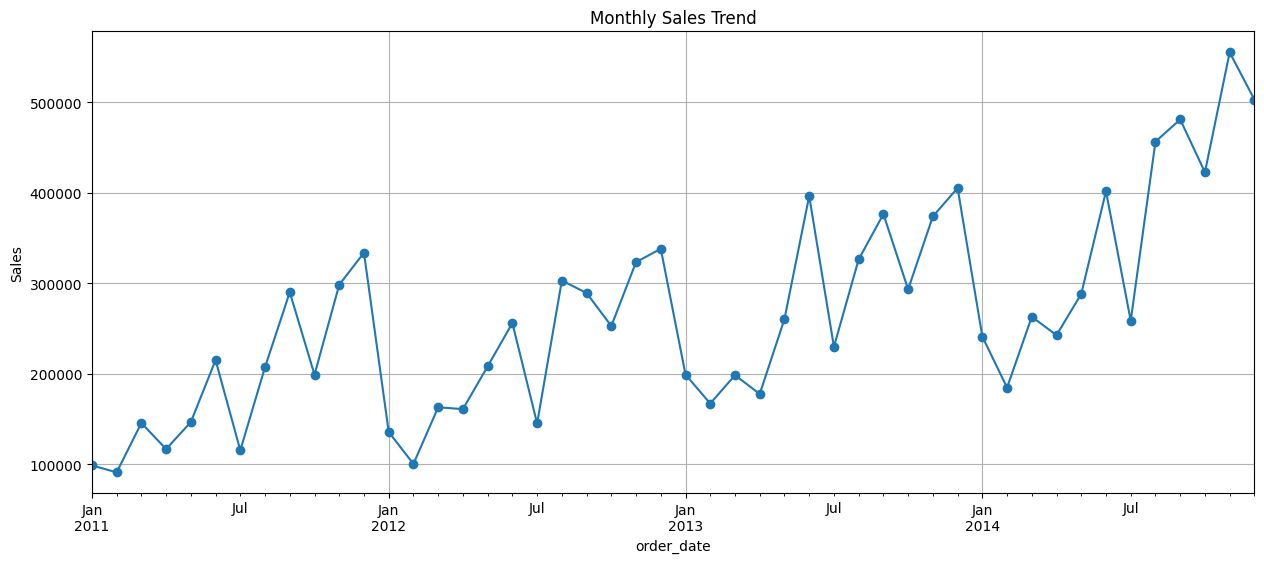

In [58]:
plt.figure(figsize=(15,6))

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

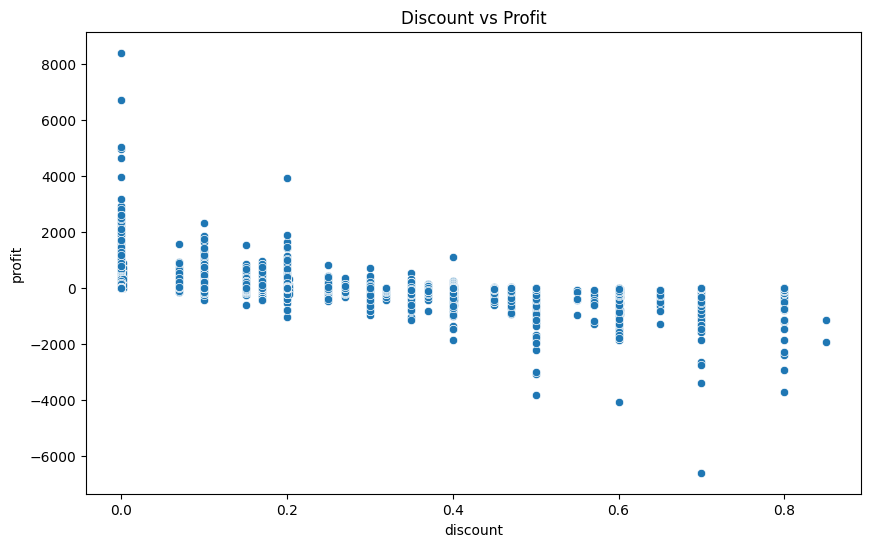

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='discount',
    y='profit'
)

plt.title("Discount vs Profit")

plt.show()

In [60]:
df.to_csv("cleaned_superstore.csv", index=False)

In [61]:
import os

print(os.getcwd())

C:\Users\vyjay


In [62]:
df.to_csv(
    "C:/Users/vyjay/Downloads/archive/cleaned_superstore.csv",
    index=False
)